In [10]:
# Block - 1
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [11]:
# Block - 2
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Import DS3000-Final Folder
import os
os.listdir('/content/drive/MyDrive/DS3000-Final')

import pandas as pd

# Loads the "ML-ready" charging-station dataset
df = pd.read_csv('/content/drive/MyDrive/DS3000-Final/station_summary_model_encoded.csv')
df.head()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,latitude,longitude,ports,power_kw,is_fast_dc,total_power_kw,total_evs,avg_battery,SUV,...,Van_pct,mostly_fast_dc,high_ev_count,power_class_AC_L1_(<7.5kW),power_class_AC_L2_(7.5-21kW),power_class_DC_FAST_(50-149kW),power_class_DC_ULTRA_(>=150kW),power_class_UNKNOWN,power_tier_Level 2,power_tier_Ultra DC
0,2389,34.040539,-118.271387,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
1,2391,34.059133,-118.248589,1,50.0,True,50.0,11,88.181818,6,...,0.0,True,True,False,False,True,False,False,False,False
2,2396,38.576769,-121.495022,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
3,2399,38.438052,-122.711357,1,NaN,False,NaN,11,88.181818,6,...,0.0,False,True,False,False,False,False,True,True,False
4,2441,34.145138,-118.152655,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False


In [12]:
# Block - 3
# ---------------------------------------------
# BUILDING THE CHARGING TIME VARIABLE (TARGET)
# ---------------------------------------------

# Convert power_kw and avg_battery to numeric
# (Errors become NaN instead of crashing the notebook.)
df["power_kw"] = pd.to_numeric(df["power_kw"], errors="coerce")
df["avg_battery"] = pd.to_numeric(df["avg_battery"], errors="coerce")

# Replace invalid charger power values (<= 0 kW) with NaN
# Because negative/zero kW would make the charge time formula blow up.
df.loc[df["power_kw"] <= 0, "power_kw"] = np.nan

# Create the estimated charging time (in minutes)
# Formula: (battery capacity in kWh / charger power in kW) * 60
# Example: 60 kWh battery on a 10 kW charger → 6 hours → 360 minutes.
df["charge_time_est_mins"] = (df["avg_battery"] / df["power_kw"]) * 60

# Print missing values BEFORE dropping invalid rows
print("Missing charging time before drop:", df["charge_time_est_mins"].isna().sum())

# Drop rows where the charge time could not be computed
df = df.dropna(subset=["charge_time_est_mins"]).reset_index(drop=True)

# Print shape AFTER dropping invalid rows
print("After drop:", df.shape)

# Remove extreme outliers in the computed target
# Keep only the 1st–99th percentile range
Q1 = df["charge_time_est_mins"].quantile(0.01)
Q3 = df["charge_time_est_mins"].quantile(0.99)

df = df[(df["charge_time_est_mins"] >= Q1) &
        (df["charge_time_est_mins"] <= Q3)].reset_index(drop=True)

print("After outlier removal:", df.shape)

# Quick summary of key numerical variables
df[["avg_battery", "power_kw", "charge_time_est_mins"]].describe()


Missing charging time before drop: 4690
After drop: (237727, 27)
After outlier removal: (234407, 27)


,avg_battery,power_kw,charge_time_est_mins
count,234407.000000,234407.000000,234407.000000
mean,79.537890,29.145353,666.666555
std,6.262990,49.961425,576.769947
min,75.000000,2.700000,15.000000
25%,75.000000,3.700000,204.545455
50%,75.000000,11.000000,409.090909
75%,88.181818,22.000000,1429.975430
max,88.181818,351.000000,1763.636364


In [13]:
# Block - 4
# Define features and target
features = [
    "power_kw",
    "total_power_kw",
    "ports",
    "avg_battery",
    "total_evs"
]

target = "charge_time_est_mins"

# Print available columns to help identify the correct target variable
print("Available columns in df:", df.columns.tolist())

X = df[features]
y = df[target]


Available columns in df: ['id', 'latitude', 'longitude', 'ports', 'power_kw', 'is_fast_dc', 'total_power_kw', 'total_evs', 'avg_battery', 'SUV', 'Pickup', 'Sedan', 'Van', 'SUV_pct', 'Pickup_pct', 'Sedan_pct', 'Van_pct', 'mostly_fast_dc', 'high_ev_count', 'power_class_AC_L1_(<7.5kW)', 'power_class_AC_L2_(7.5-21kW)', 'power_class_DC_FAST_(50-149kW)', 'power_class_DC_ULTRA_(>=150kW)', 'power_class_UNKNOWN', 'power_tier_Level 2', 'power_tier_Ultra DC', 'charge_time_est_mins']


In [14]:
# Block - 5
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Block - 6
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# Block - 7
# Baseline: Multiple Linear Regression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

pred_train = linreg.predict(X_train_scaled)
pred_test = linreg.predict(X_test_scaled)

baseline_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
    "Train MAE": mean_absolute_error(y_train, pred_train),
    "Test MAE": mean_absolute_error(y_test, pred_test),
    "R2": r2_score(y_test, pred_test),
}

baseline_results


{'Train RMSE': np.float64(371.2147820257535),
 'Test RMSE': np.float64(371.92062148203814),
 'Train MAE': 298.5024298248108,
 'Test MAE': 299.3566601935005,
 'R2': 0.5840884598073793}

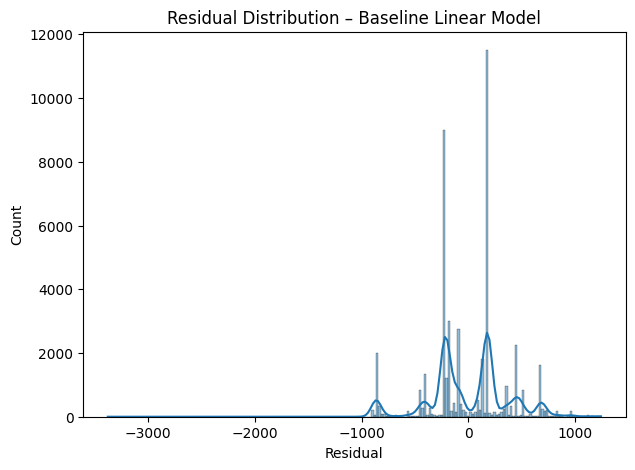

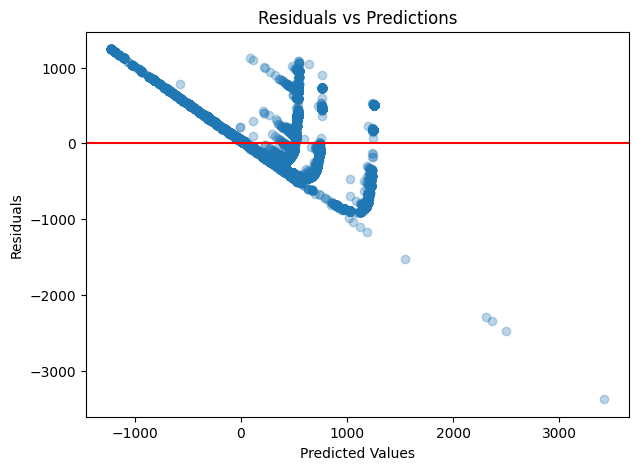

In [17]:
# Block - 8
# Residual plots
residuals = y_test - pred_test

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution – Baseline Linear Model")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(pred_test, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [18]:
# Block - 9
# Maximum Likelihood
# Negative log-likelihood under Gaussian noise assumption
sigma2 = np.mean(residuals ** 2)
n = len(residuals)

nll = 0.5 * n * np.log(2 * np.pi * sigma2) + np.sum(residuals**2) / (2 * sigma2)
nll

np.float64(344002.25309516507)